# Network Metrics — IBD Joint Network

Computes all pre-specified network metrics on the joint network inferred by GLASSO
(piGLASSO, 3 omics layers: MGX + MBX + HTX).

**METHOD**

Core metrics (primary research questions):
1. Global topology — density, average path length, diameter
2. Degree + betweenness centrality — hub node identification
3. Community detection (Louvain) — functional modules
4. Cross-layer edges — inter-modality bridges
5. Cross-community edges — surprising long-range connections
6. RWR diffusion scores — disease-relevance ranking from configurable seed nodes

Add-on metrics:
7. Eigenvector centrality — nuanced hub detection
8. Within-community cohesion — internal density + conductance
9. Layer contribution — metric changes on layer removal

**LIMITATIONS**

Not in this notebook: IBD vs. non-IBD comparison. A separately-fit control
network was considered and rejected (n=22 is far too small); the adopted design
holds the pooled topology fixed and re-estimates edge weights per group instead.
See `04_subgroup_comparison.py`.

**RUN**

Edit the `CONFIG` dict in the next cell to set paths, seed nodes, and analysis
parameters before running. Run headlessly via `03_run_network_metrics.py`
(requires `GLASSO/results/ibd/seed_selection.csv` to already exist), or
interactively top to bottom.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

from networkx.algorithms.community import louvain_communities
import networkx.algorithms.community as nx_comm

plt.rcParams.update({
    "figure.dpi"    : 120,
    "font.size"     : 11,
    "axes.grid"     : True,
    "grid.alpha"    : 0.3,
    "axes.axisbelow": True,
})

# ── USER CONFIGURATION ───────────────────────────────────────────────────────
CONFIG = {
    # Path to the inferred network (GraphML from the GLASSO pipeline)
    "graphml_path"   : "../GLASSO/results/ibd/ibd_joint_network.graphml",

    # Directory for saving result figures and CSV
    "results_dir"    : "../GLASSO/results/ibd/",

    # RWR seeds are NOT hardcoded here. They are derived by 02_seed_selection.py from
    # evidence external to this cohort and read from the table below, so that a
    # pipeline rerun re-derives them rather than inheriting a stale hand-edited list.
    # See the loader immediately after this dict.
    "seed_table"     : "../GLASSO/results/ibd/seed_selection.csv",

    # RWR restart probability (0.2-0.5 typical; higher = more local)
    "rwr_alpha"      : 0.3,

    # Random seed for Louvain and layout reproducibility
    "seed"           : 42,

    # Node attribute encoding the omics layer / modality
    "modality_attr"  : "modality",

    # Expected modality values and their display colours
    "modality_colours": {
        "microbiome": "#4C9BE8",
        "metabolite" : "#E8834C",
        "transcript" : "#5CB85C",
    },

    # Edge attribute encoding the layer pair
    "edge_type_attr" : "edge_type",

    # Edge types that are cross-layer (vs within-layer)
    "cross_layer_types"  : {"mgx-mbx", "mgx-rna", "mbx-rna"},
    "within_layer_types" : {"mgx-mgx", "mbx-mbx", "rna-rna"},

    # Display colours per edge type
    "edge_type_colours": {
        "mgx-mgx": "#4C9BE8", "mbx-mbx": "#E8834C", "rna-rna": "#5CB85C",
        "mgx-mbx": "#888888", "mgx-rna": "#A569BD", "mbx-rna": "#D4AC0D",
    },
}
# ────────────────────────────────────────────────────────────────────────────

# ── RWR SEED LOADING ─────────────────────────────────────────────────────────
# A node is admitted as a seed only if it carries evidence of IBD association that
# is independent of this cohort. Every node in the network was selected using the
# IBD/non-IBD labels, so seeds derived from the network itself would make the
# diffusion result circular in the same way node selection is. External seeds are
# the one part of the analysis not conditioned on the outcome labels.
#
#   transcripts  Open Targets Platform association score for IBD (MONDO_0005265).
#   microbiome   PubMed co-occurrence screen, then evidence review of the ranked
#                candidates; admitted species carry recorded PMIDs.
#   metabolites  excluded, since most nodes have no confirmed chemical identity.
#
# Regenerate with:  python 02_seed_selection.py --write
# Do NOT paste a seed list back into this cell. If the rule needs to change, change
# it in 02_seed_selection.py so that the change is recorded and rerunnable.
seed_path = CONFIG["seed_table"]
if not os.path.exists(seed_path):
    raise FileNotFoundError(
        f"Seed table not found: {seed_path}\n"
        "Run `python 02_seed_selection.py --write` first. Seeds are derived, not hardcoded; "
        "see the seed-selection rule in the Methodology."
    )
_seed_tbl = pd.read_csv(seed_path)
CONFIG["rwr_seeds"] = sorted(_seed_tbl.loc[_seed_tbl["admitted"], "node"])
print(f"RWR seeds loaded from {os.path.basename(seed_path)}: {CONFIG['rwr_seeds']}")
# ────────────────────────────────────────────────────────────────────────────

os.makedirs(CONFIG["results_dir"], exist_ok=True)
print("Configuration loaded.")


RWR seeds loaded from seed_selection.csv: ['C18n_QI6559', 'CXCR1', 'CXCR2', 'Clostridium_innocuum', 'Roseburia_hominis']
Configuration loaded.


## Load network

In [2]:
G = nx.read_graphml(CONFIG["graphml_path"])
SEED          = CONFIG["seed"]
modality_attr = CONFIG["modality_attr"]
edge_type_attr = CONFIG["edge_type_attr"]
MODALITY_COLOURS  = CONFIG["modality_colours"]
EDGE_TYPE_COLOURS = CONFIG["edge_type_colours"]
CROSS_LAYER_TYPES  = CONFIG["cross_layer_types"]
WITHIN_LAYER_TYPES = CONFIG["within_layer_types"]

print(f"Nodes  : {G.number_of_nodes()}")
print(f"Edges  : {G.number_of_edges()}")

all_modalities = sorted(set(
    d.get(modality_attr, "unknown") for _, d in G.nodes(data=True)
))
modality_counts = pd.Series(
    {m: sum(1 for _, d in G.nodes(data=True) if d.get(modality_attr) == m)
     for m in all_modalities}
)
print(f"\nNodes by modality:\n{modality_counts.to_string()}")

edge_type_counts = pd.Series(
    [d.get(edge_type_attr, "unknown") for _, _, d in G.edges(data=True)]
).value_counts()
print(f"\nEdges by type:\n{edge_type_counts.to_string()}")

weights = [d.get("weight", 0) for _, _, d in G.edges(data=True)]
print(f"\nEdge weights — range: [{min(weights):.4f}, {max(weights):.4f}]")
print("(Negative weights = negative partial correlations; sign encodes direction, "
      "not absence of relationship)")


Nodes  : 75
Edges  : 454

Nodes by modality:
metabolite    25
microbiome    25
transcript    25

Edges by type:
rna-rna    159
mbx-mbx    145
mgx-mgx     66
mgx-mbx     50
mbx-rna     31
mgx-rna      3

Edge weights — range: [-0.1552, 0.4594]
(Negative weights = negative partial correlations; sign encodes direction, not absence of relationship)


## 1. Global topology

Density, average path length, and diameter characterise the overall wiring.
Most useful for cross-condition or cross-layer comparisons rather than as
standalone outputs.


Global topology
------------------------------
Nodes                  75
Edges                 454
Density            0.1636
Avg degree          12.11
Avg path length     2.382
Diameter                6
Is connected         True


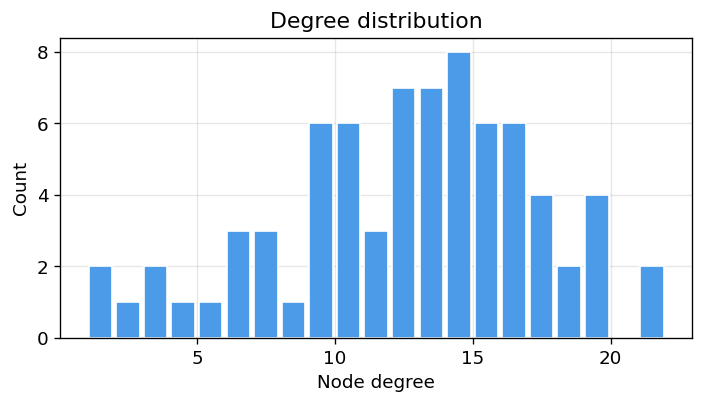

In [3]:
density    = nx.density(G)
avg_degree = np.mean([d for _, d in G.degree()])
connected  = nx.is_connected(G)

if connected:
    apl      = nx.average_shortest_path_length(G)
    diameter = nx.diameter(G)
else:
    lcc      = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    apl      = nx.average_shortest_path_length(lcc)
    diameter = nx.diameter(lcc)
    print("Graph is disconnected; path length / diameter on largest component.")

topology = pd.Series({
    "Nodes"           : G.number_of_nodes(),
    "Edges"           : G.number_of_edges(),
    "Density"         : round(density, 4),
    "Avg degree"      : round(avg_degree, 2),
    "Avg path length" : round(apl, 3),
    "Diameter"        : diameter,
    "Is connected"    : connected,
})
print("Global topology\n" + "-" * 30)
print(topology.to_string())

# Degree distribution
degrees = [d for _, d in G.degree()]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(degrees, bins=range(min(degrees), max(degrees) + 2),
        color="#4C9BE8", edgecolor="white", rwidth=0.85)
ax.set_xlabel("Node degree")
ax.set_ylabel("Count")
ax.set_title("Degree distribution")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "metric_degree_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 2. Centrality metrics

**Degree centrality** — most directly connected nodes (local hubs).
**Betweenness centrality** — nodes on the most shortest paths (bridges / bottlenecks).
**Eigenvector centrality** — nodes connected to other highly connected nodes
(quality over quantity; rewards influence propagation).

Hub nodes rank highly across all three. A composite hub rank averages the
three rank positions (lower composite rank = more central).


In [4]:
def _abs_weight_graph(H):
    """Copy of H with weight -> abs(weight); centrality on magnitude, not sign."""
    HA = nx.Graph()
    HA.add_nodes_from(H.nodes(data=True))
    for u, v, d in H.edges(data=True):
        HA.add_edge(u, v, weight=abs(d.get("weight", 1.0)))
    return HA

def _dist_weight_graph(H):
    """Copy of H with weight -> 1/abs(weight); strong edges become short paths for betweenness."""
    HD = nx.Graph()
    HD.add_nodes_from(H.nodes(data=True))
    for u, v, d in H.edges(data=True):
        w = abs(d.get("weight", 1.0))
        HD.add_edge(u, v, weight=(1.0 / w) if w > 0 else float("inf"))
    return HD

print("Computing degree centrality ...")
degree_centrality = nx.degree_centrality(G)

print("Computing betweenness centrality (weighted) ...")
betweenness = nx.betweenness_centrality(_dist_weight_graph(G), weight="weight", normalized=True)

print("Computing eigenvector centrality ...")
try:
    eigenvector = nx.eigenvector_centrality(_abs_weight_graph(G), weight="weight",
                                            max_iter=1000, tol=1e-6)
except nx.PowerIterationFailedConvergence:
    print("  [eigenvector] weighted did not converge; using unweighted")
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

centrality_df = pd.DataFrame({
    "modality"          : nx.get_node_attributes(G, modality_attr),
    "degree"            : dict(G.degree()),
    "degree_centrality" : degree_centrality,
    "betweenness"       : betweenness,
    "eigenvector"       : eigenvector,
})

# Composite hub rank (lower = more central)
for col in ["degree_centrality", "betweenness", "eigenvector"]:
    centrality_df[f"{col}_rank"] = centrality_df[col].rank(ascending=False)
centrality_df["hub_rank"] = (
    centrality_df["degree_centrality_rank"]
    + centrality_df["betweenness_rank"]
    + centrality_df["eigenvector_rank"]
) / 3
centrality_df = centrality_df.sort_values("hub_rank")

print("\n-- Top 15 hub nodes (composite rank) --")
print(centrality_df[
    ["modality", "degree", "degree_centrality", "betweenness", "eigenvector", "hub_rank"]
].head(15).round(5).to_string())


Computing degree centrality ...
Computing betweenness centrality (weighted) ...
Computing eigenvector centrality ...



-- Top 15 hub nodes (composite rank) --
                modality  degree  degree_centrality  betweenness  eigenvector  hub_rank
CSF3          transcript      16            0.21622      0.13328      0.14999  12.16667
FCGR3B        transcript      15            0.20270      0.04369      0.22146  15.33333
SAA1          transcript      17            0.22973      0.03110      0.19211  15.50000
C4BPB         transcript      19            0.25676      0.02592      0.18961  15.50000
HILn_QI3463   metabolite      21            0.28378      0.05109      0.10421  15.83333
SAA2          transcript      13            0.17568      0.11366      0.18910  16.66667
HILn_QI18128  metabolite      19            0.25676      0.05887      0.09792  16.83333
C6orf223      transcript      17            0.22973      0.04776      0.13496  17.50000
C18n_QI7499   metabolite      19            0.25676      0.04369      0.10521  19.00000
CXCR2         transcript      14            0.18919      0.03739      0.20764  

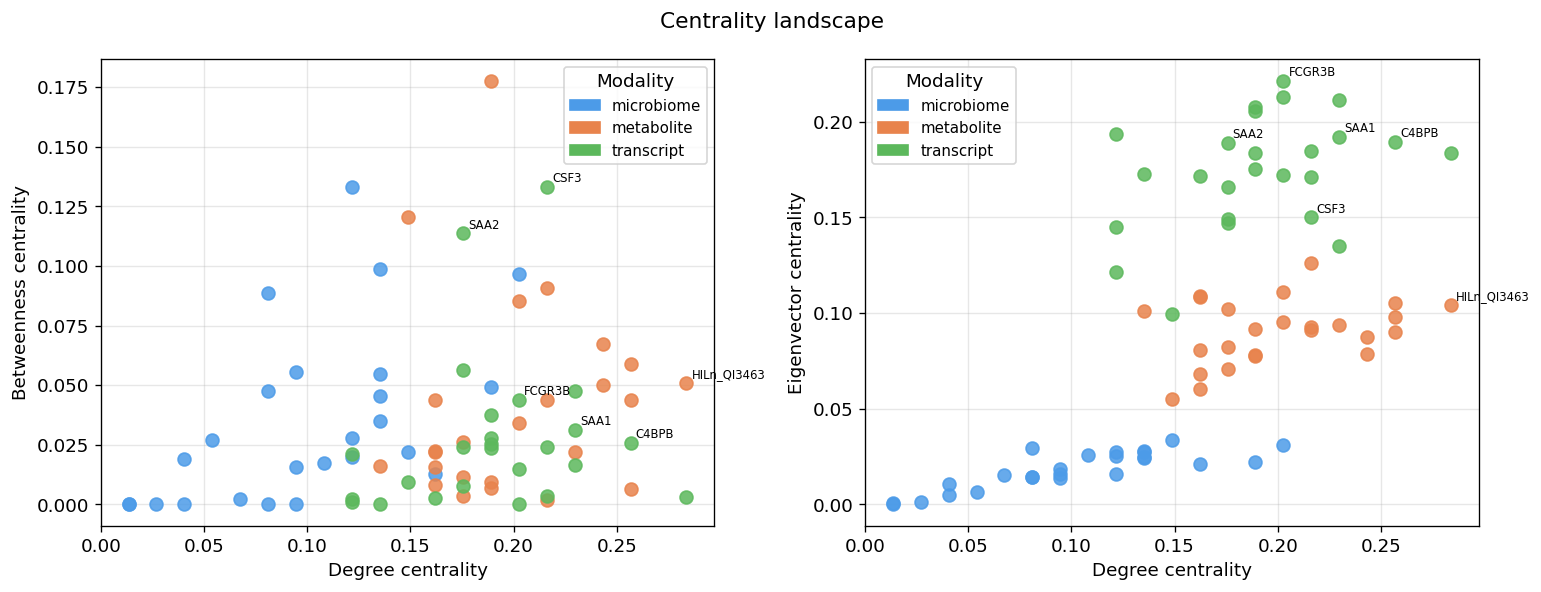

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pairs = [
    ("degree_centrality", "betweenness", "Degree centrality", "Betweenness centrality"),
    ("degree_centrality", "eigenvector", "Degree centrality", "Eigenvector centrality"),
]
for ax, (xc, yc, xl, yl) in zip(axes, pairs):
    for mod, colour in MODALITY_COLOURS.items():
        sub = centrality_df[centrality_df.modality == mod]
        ax.scatter(sub[xc], sub[yc], c=colour, label=mod, s=60, alpha=0.85, zorder=3)
    for node, row in centrality_df.head(6).iterrows():
        ax.annotate(node, (row[xc], row[yc]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    handles = [mpatches.Patch(color=c, label=m) for m, c in MODALITY_COLOURS.items()]
    ax.legend(handles=handles, title="Modality", fontsize=9)
fig.suptitle("Centrality landscape", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "metric_centrality_scatter.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 3. Community detection (Louvain)

Louvain maximises modularity Q ∈ [-1, 1]. Q > 0.3 indicates meaningful
community structure. Absolute edge weights are used because negative partial
correlations encode conditional dependence (not absence of coupling) — both
positive and negative edges belong to the same structural community.


In [6]:
# Build graph with absolute weights for Louvain
G_abs = nx.Graph()
G_abs.add_nodes_from(G.nodes(data=True))
for u, v, d in G.edges(data=True):
    G_abs.add_edge(u, v, weight=abs(d.get("weight", 1.0)))

communities = louvain_communities(G_abs, weight="weight", seed=SEED)
modularity_q = nx_comm.modularity(G_abs, communities, weight="weight")

print(f"Communities detected : {len(communities)}")
print(f"Modularity Q         : {modularity_q:.4f}")

# Assign community IDs as node attributes
community_map = {}
for cid, comm in enumerate(communities):
    for node in comm:
        community_map[node] = cid
nx.set_node_attributes(G, community_map, "community")

# Community composition table
comm_records = []
for cid, comm in enumerate(communities):
    mods = pd.Series([G.nodes[n].get(modality_attr, "?") for n in comm]).value_counts().to_dict()
    comm_records.append({"community": cid, "size": len(comm), **mods})
comm_df = pd.DataFrame(comm_records).fillna(0)
for col in all_modalities:
    if col in comm_df.columns:
        comm_df[col] = comm_df[col].astype(int)
print("\n-- Community composition --")
print(comm_df.to_string(index=False))


Communities detected : 5
Modularity Q         : 0.6029

-- Community composition --
 community  size  metabolite  microbiome  transcript
         0     6           6           0           0
         1    23           0          23           0
         2    21          19           2           0
         3    10           0           0          10
         4    15           0           0          15


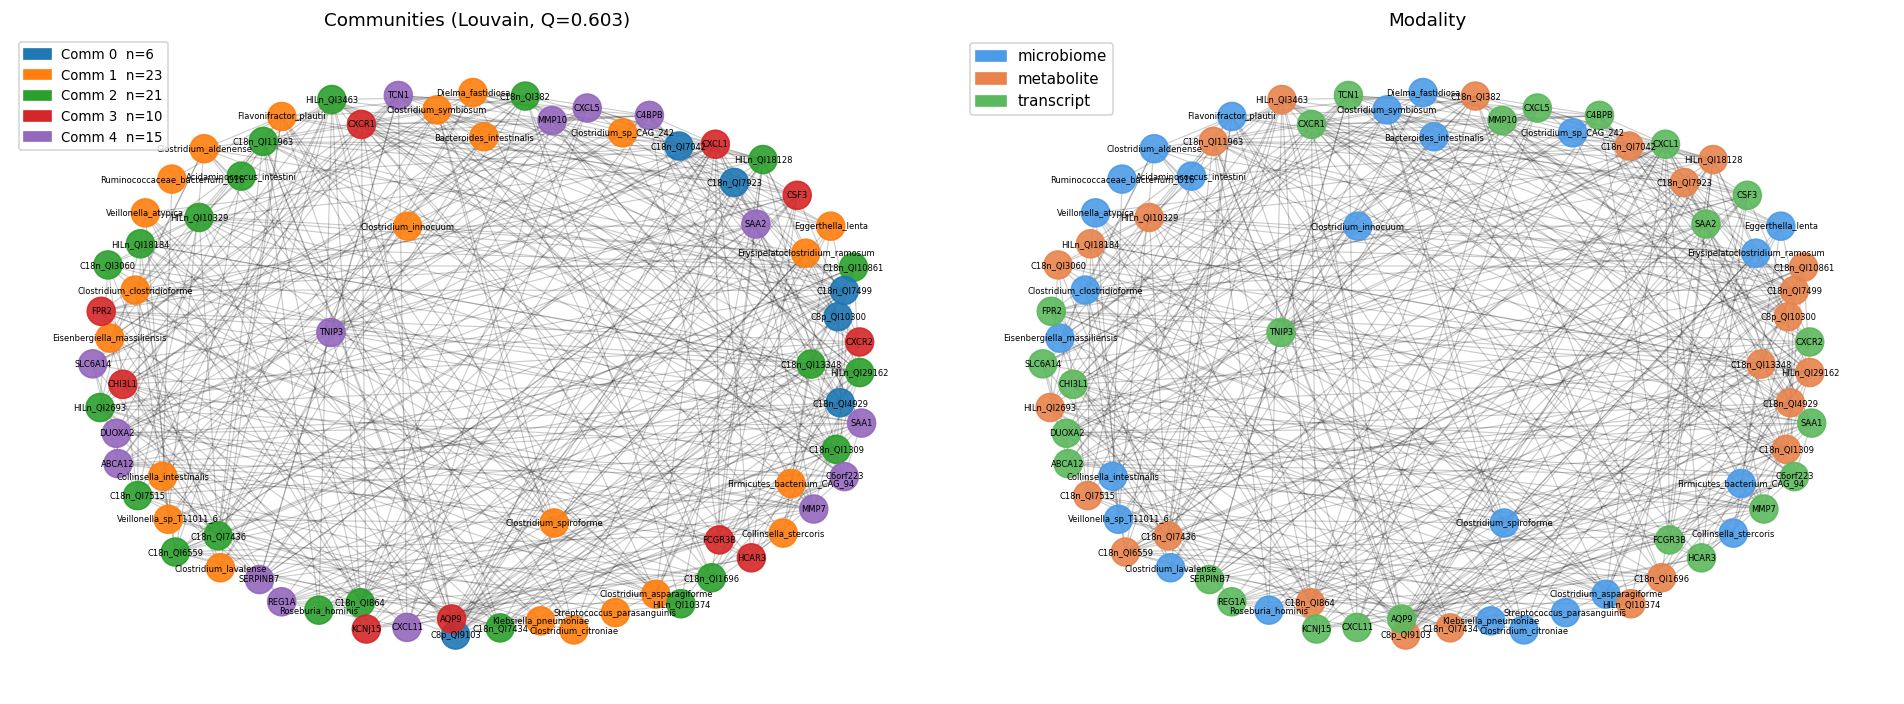

In [7]:
COMM_COLOURS = plt.cm.tab10.colors
pos = nx.spring_layout(G, seed=SEED, k=1.5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: coloured by community
ax = axes[0]
node_comm_colours = [COMM_COLOURS[community_map[n] % 10] for n in G.nodes()]
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.7, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_comm_colours,
                       node_size=280, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=5, ax=ax)
ax.set_title(f"Communities (Louvain, Q={modularity_q:.3f})", fontsize=11)
ax.axis("off")
legend_handles = [
    mpatches.Patch(color=COMM_COLOURS[i], label=f"Comm {i}  n={len(list(communities[i]))}")
    for i in range(len(communities))
]
ax.legend(handles=legend_handles, fontsize=8, loc="upper left")

# Right: coloured by modality
ax = axes[1]
mod_colours = [MODALITY_COLOURS.get(G.nodes[n].get(modality_attr, ""), "#ccc")
               for n in G.nodes()]
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.7, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=mod_colours, node_size=280, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=5, ax=ax)
ax.set_title("Modality", fontsize=11)
ax.axis("off")
handles = [mpatches.Patch(color=c, label=m) for m, c in MODALITY_COLOURS.items()]
ax.legend(handles=handles, fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "metric_community_network.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 4. Cross-layer edges

Edges connecting nodes from different omics layers (MGX-MBX, MGX-RNA, MBX-RNA).
These are the primary targets for biological interpretation as they encode
conditional dependencies across biological levels.


In [8]:
cross_edges  = [(u, v, d) for u, v, d in G.edges(data=True)
                if d.get(edge_type_attr) in CROSS_LAYER_TYPES]
within_edges = [(u, v, d) for u, v, d in G.edges(data=True)
                if d.get(edge_type_attr) in WITHIN_LAYER_TYPES]

n_total  = G.number_of_edges()
n_cross  = len(cross_edges)
n_within = len(within_edges)

print(f"Total edges          : {n_total}")
print(f"Within-layer edges   : {n_within} ({100*n_within/n_total:.1f}%)")
print(f"Cross-layer edges    : {n_cross}  ({100*n_cross/n_total:.1f}%)")
print()

cross_df = pd.DataFrame(
    [(d[edge_type_attr], abs(d.get("weight", 0))) for _, _, d in cross_edges],
    columns=["edge_type", "abs_weight"]
)
print(cross_df.groupby("edge_type")["abs_weight"]
      .agg(["count", "mean", "std", "max"]).round(4))

# Nodes acting as cross-layer integration hubs
cross_degree = {}
for u, v, _ in cross_edges:
    cross_degree[u] = cross_degree.get(u, 0) + 1
    cross_degree[v] = cross_degree.get(v, 0) + 1
cross_degree_s = pd.Series(cross_degree).sort_values(ascending=False)

print("\n-- Top 12 cross-layer integration hubs --")
for node, cnt in cross_degree_s.head(12).items():
    mod = G.nodes[node].get(modality_attr, "?")
    print(f"  {node:<40s} [{mod}]  cross-layer degree = {cnt}")


Total edges          : 454
Within-layer edges   : 370 (81.5%)
Cross-layer edges    : 84  (18.5%)

           count    mean     std     max
edge_type                               
mbx-rna       31  0.0210  0.0180  0.0747
mgx-mbx       50  0.0303  0.0243  0.1100
mgx-rna        3  0.0345  0.0346  0.0743

-- Top 12 cross-layer integration hubs --
  C18n_QI7499                              [metabolite]  cross-layer degree = 10
  C18n_QI4929                              [metabolite]  cross-layer degree = 8
  Dielma_fastidiosa                        [microbiome]  cross-layer degree = 7
  Roseburia_hominis                        [microbiome]  cross-layer degree = 6
  Collinsella_stercoris                    [microbiome]  cross-layer degree = 6
  HILn_QI18128                             [metabolite]  cross-layer degree = 6
  C18n_QI13348                             [metabolite]  cross-layer degree = 6
  AQP9                                     [transcript]  cross-layer degree = 5
  C8p_QI9103 

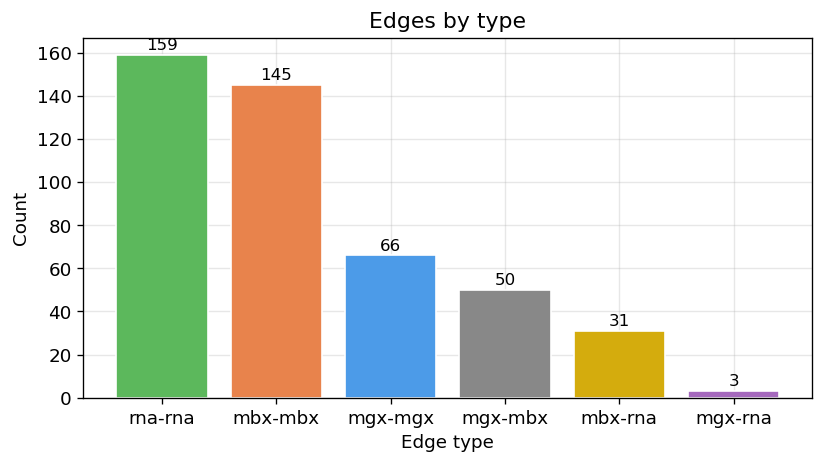

In [9]:
all_et = pd.Series(
    [d.get(edge_type_attr, "?") for _, _, d in G.edges(data=True)]
).value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
colours = [EDGE_TYPE_COLOURS.get(et, "#ccc") for et in all_et.index]
ax.bar(all_et.index, all_et.values, color=colours, edgecolor="white")
for i, (et, cnt) in enumerate(all_et.items()):
    ax.text(i, cnt + 1, str(cnt), ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Edge type")
ax.set_ylabel("Count")
ax.set_title("Edges by type")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "metric_edge_type_counts.png"),
            dpi=150, bbox_inches="tight")
plt.show()


## 5. Cross-community edges

Edges that bridge different Louvain communities. The most biologically interesting
subset is **cross-layer AND cross-community**: edges connecting nodes from different
omics modalities that do not belong to the same functional module — candidates for
previously unknown inter-system regulatory relationships.


In [10]:
cross_comm_edges  = [(u, v, d) for u, v, d in G.edges(data=True)
                     if community_map[u] != community_map[v]]
within_comm_edges = [(u, v, d) for u, v, d in G.edges(data=True)
                     if community_map[u] == community_map[v]]

print(f"Within-community edges         : {len(within_comm_edges)} ({100*len(within_comm_edges)/n_total:.1f}%)")
print(f"Cross-community edges          : {len(cross_comm_edges)}  ({100*len(cross_comm_edges)/n_total:.1f}%)")

# Cross-layer AND cross-community
surprising = [
    (u, v, d) for u, v, d in G.edges(data=True)
    if d.get(edge_type_attr) in CROSS_LAYER_TYPES
    and community_map[u] != community_map[v]
]
print(f"Cross-layer AND cross-community: {len(surprising)}")

surprising_df = pd.DataFrame([
    {
        "source"      : u,
        "target"      : v,
        "source_mod"  : G.nodes[u].get(modality_attr, "?"),
        "target_mod"  : G.nodes[v].get(modality_attr, "?"),
        "edge_type"   : d.get(edge_type_attr),
        "weight"      : round(d.get("weight", float("nan")), 5),
        "source_comm" : community_map[u],
        "target_comm" : community_map[v],
    }
    for u, v, d in surprising
]).sort_values("weight", key=abs, ascending=False)

print("\n-- Cross-layer x cross-community edges (|weight| descending) --")
print(surprising_df.to_string(index=False))


Within-community edges         : 301 (66.3%)
Cross-community edges          : 153  (33.7%)
Cross-layer AND cross-community: 80

-- Cross-layer x cross-community edges (|weight| descending) --
                        source       target source_mod target_mod edge_type   weight  source_comm  target_comm
         Clostridium_symbiosum  C8p_QI10300 microbiome metabolite   mgx-mbx  0.11004            1            0
        Flavonifractor_plautii   C8p_QI9103 microbiome metabolite   mgx-mbx -0.07763            1            0
                  C18n_QI13348         SAA2 metabolite transcript   mbx-rna -0.07467            2            4
     Clostridium_asparagiforme         CSF3 microbiome transcript   mgx-rna  0.07435            1            3
             Dielma_fastidiosa  C18n_QI7042 microbiome metabolite   mgx-mbx  0.06814            1            0
   Clostridium_clostridioforme  C18n_QI4929 microbiome metabolite   mgx-mbx  0.06477            1            0
             Dielma_fastidiosa 

## 6. RWR diffusion scores — disease-relevance

Random Walk with Restart (RWR) propagates a signal placed on seed nodes
through the network, ranking all nodes by proximity to the disease seeds.

**Formula**: r(t+1) = (1 − α) · W · r(t) + α · seed
where W is the column-stochastic transition matrix (absolute weights) and α
is the restart probability.

**Seeds are derived, not set by hand.** `CONFIG["rwr_seeds"]` is populated in the
configuration cell from `seed_selection.csv`, which `02_seed_selection.py` builds from
evidence external to this cohort: Open Targets IBD association scores for transcripts,
and a PubMed screen plus evidence review for microbial species. Metabolites are
excluded because most nodes have no confirmed chemical identity.

This matters for interpretation. Every node in the network was selected using the
IBD/non-IBD labels, so seeding from network-derived candidates would make the
diffusion ranking circular in the same way node selection is. External seeds are the
one part of the analysis not conditioned on the outcome labels.

Seed choice is not a minor knob: rank correlation between the current seed set and
the earlier hand-picked one is ρ = 0.55 across all 75 nodes. To change the rule, edit
`02_seed_selection.py` and rerun it — do not paste a list back into the config cell.


In [11]:
def rwr(G, seed_nodes, alpha=0.3, max_iter=2000, tol=1e-10):
    """
    Random Walk with Restart on a NetworkX graph.

    Parameters
    ----------
    G          : NetworkX graph (edge weight attribute used; absolute values taken)
    seed_nodes : list of node names to seed the walk
    alpha      : restart probability (0-1)
    max_iter   : maximum power-iteration steps
    tol        : L1-norm convergence threshold

    Returns
    -------
    dict {node: score}  (scores sum to 1)
    """
    nodes    = list(G.nodes())
    n        = len(nodes)
    node_idx = {node: i for i, node in enumerate(nodes)}

    A = nx.to_numpy_array(G, nodelist=nodes, weight="weight")
    A = np.abs(A)

    # Column-stochastic transition matrix
    col_sums = A.sum(axis=0, keepdims=True)
    col_sums[col_sums == 0] = 1
    W = A / col_sums

    valid_seeds = [s for s in seed_nodes if s in node_idx]
    if not valid_seeds:
        raise ValueError(
            f"No seed nodes found in graph.\n"
            f"Requested: {seed_nodes}\n"
            f"Available nodes: {sorted(node_idx.keys())}"
        )
    print(f"Active seed nodes ({len(valid_seeds)}/{len(seed_nodes)}): {valid_seeds}")

    seed_vec = np.zeros(n)
    for s in valid_seeds:
        seed_vec[node_idx[s]] = 1.0
    seed_vec /= seed_vec.sum()

    r = seed_vec.copy()
    for iteration in range(max_iter):
        r_new = (1 - alpha) * (W @ r) + alpha * seed_vec
        if np.linalg.norm(r_new - r, ord=1) < tol:
            print(f"Converged at iteration {iteration + 1}")
            break
        r = r_new
    else:
        print(f"Did not converge within {max_iter} iterations "
              f"(residual = {np.linalg.norm(r_new - r, ord=1):.2e})")

    return {nodes[i]: float(r[i]) for i in range(n)}


rwr_seeds = CONFIG["rwr_seeds"]
rwr_alpha = CONFIG["rwr_alpha"]

if not rwr_seeds:
    print("rwr_seeds is empty — skipping RWR.")
    print("Set CONFIG[\"rwr_seeds\"] to a list of node names and re-run this cell.")
    rwr_scores = None
    rwr_df     = None
else:
    rwr_scores = rwr(G, rwr_seeds, alpha=rwr_alpha)
    rwr_df = pd.DataFrame.from_dict(rwr_scores, orient="index", columns=["rwr_score"])
    rwr_df["modality"]  = rwr_df.index.map(lambda n: G.nodes[n].get(modality_attr, "?"))
    rwr_df["community"] = rwr_df.index.map(community_map)
    rwr_df["is_seed"]   = rwr_df.index.isin(rwr_seeds)
    rwr_df = rwr_df.sort_values("rwr_score", ascending=False)
    print("\n-- Top 25 nodes by RWR disease-relevance score --")
    print(rwr_df.head(25).round(6).to_string())


Active seed nodes (5/5): ['C18n_QI6559', 'CXCR1', 'CXCR2', 'Clostridium_innocuum', 'Roseburia_hominis']
Converged at iteration 42

-- Top 25 nodes by RWR disease-relevance score --
                                rwr_score    modality  community  is_seed
CXCR1                            0.080666  transcript          3     True
CXCR2                            0.080245  transcript          3     True
Clostridium_innocuum             0.079081  microbiome          1     True
C18n_QI6559                      0.069893  metabolite          2     True
Roseburia_hominis                0.062979  microbiome          2     True
C18n_QI11963                     0.030197  metabolite          2    False
Clostridium_spiroforme           0.025832  microbiome          1    False
KCNJ15                           0.025164  transcript          3    False
FCGR3B                           0.024549  transcript          3    False
FPR2                             0.022015  transcript          3    False
AQP9 

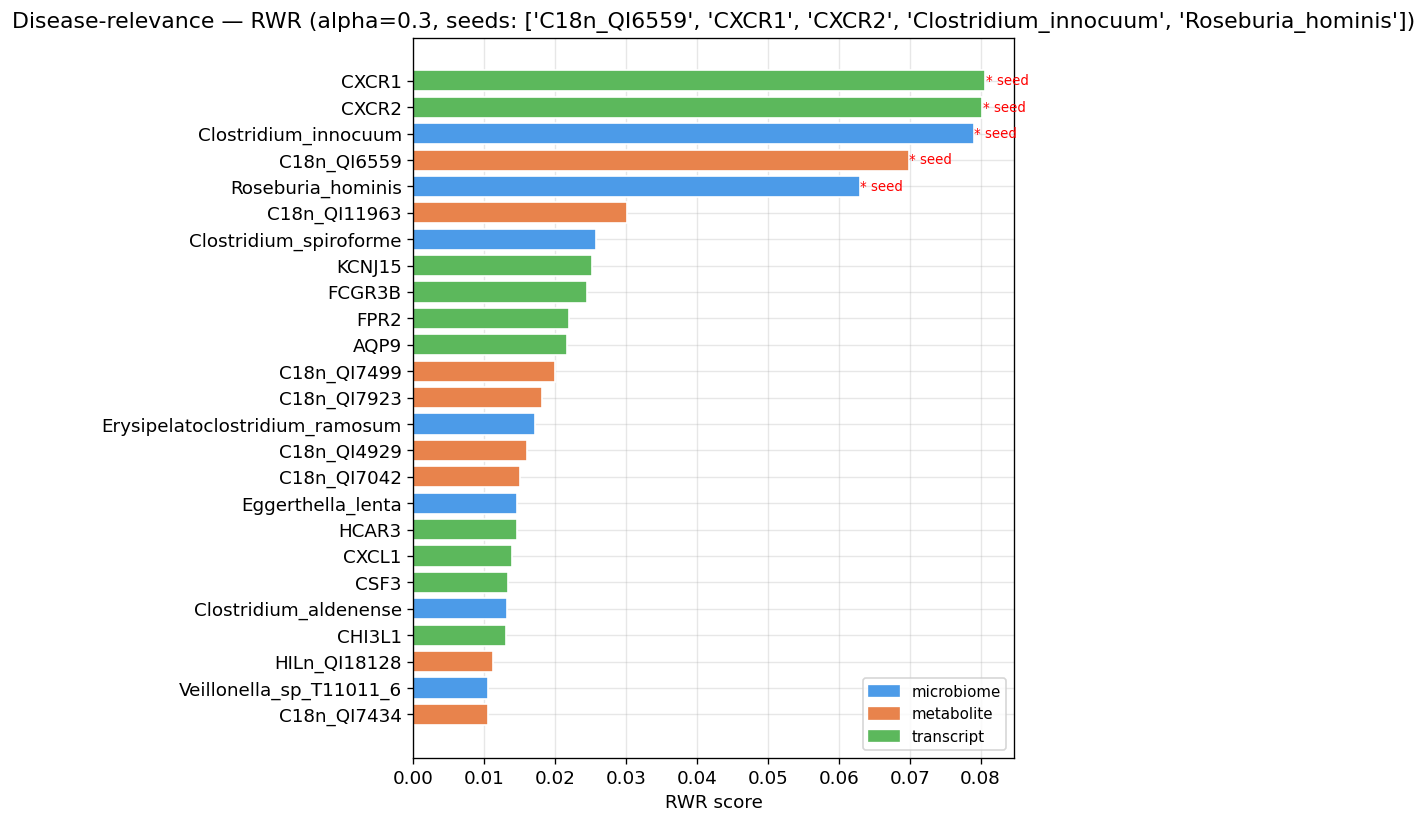

Active seed nodes (5/5): ['C18n_QI6559', 'CXCR1', 'CXCR2', 'Clostridium_innocuum', 'Roseburia_hominis']
Converged at iteration 60
Active seed nodes (5/5): ['C18n_QI6559', 'CXCR1', 'CXCR2', 'Clostridium_innocuum', 'Roseburia_hominis']
Converged at iteration 42
Active seed nodes (5/5): ['C18n_QI6559', 'CXCR1', 'CXCR2', 'Clostridium_innocuum', 'Roseburia_hominis']
Converged at iteration 24
-- RWR rank stability across alpha values (top 20 non-seed nodes) --
                                rank_a0.2  rank_a0.3  rank_a0.5
C18n_QI11963                            1          1          1
Clostridium_spiroforme                  3          2          2
KCNJ15                                  4          3          3
FCGR3B                                  2          4          4
FPR2                                    6          5          5
AQP9                                    5          6          6
C18n_QI7499                             7          7          7
C18n_QI7923                  

In [12]:
if rwr_df is not None:
    top_rwr = rwr_df.head(25).copy()
    fig, ax = plt.subplots(figsize=(8, 7))
    bar_colours = [MODALITY_COLOURS.get(m, "#ccc") for m in top_rwr["modality"]]
    ax.barh(top_rwr.index[::-1], top_rwr["rwr_score"][::-1],
            color=bar_colours[::-1], edgecolor="white")
    for i, (node, row) in enumerate(top_rwr[::-1].iterrows()):
        if row["is_seed"]:
            ax.text(row["rwr_score"] + 5e-5, i,
                    "* seed", va="center", fontsize=8, color="red")
    ax.set_xlabel("RWR score")
    ax.set_title(
        f"Disease-relevance — RWR (alpha={rwr_alpha}, seeds: {rwr_seeds})"
    )
    handles = [mpatches.Patch(color=c, label=m) for m, c in MODALITY_COLOURS.items()]
    ax.legend(handles=handles, loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["results_dir"], "metric_rwr_scores.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

    # Alpha sensitivity: compare 0.2, 0.3, 0.5
    alpha_vals = [0.2, 0.3, 0.5]
    rwr_by_alpha = {
        a: pd.Series(rwr(G, rwr_seeds, alpha=a)).sort_values(ascending=False)
        for a in alpha_vals
    }
    non_seed_nodes = [n for n in rwr_df.index if n not in rwr_seeds]
    sensitivity_df = pd.DataFrame({
        f"rank_a{a}": rwr_by_alpha[a].reindex(non_seed_nodes).rank(ascending=False).astype(int)
        for a in alpha_vals
    }).loc[non_seed_nodes[:20]]
    print("-- RWR rank stability across alpha values (top 20 non-seed nodes) --")
    print(sensitivity_df.to_string())


## 7. Within-community cohesion

**Internal density**: fraction of within-community edges realised out of all
possible pairs. Ranges 0-1; higher = tighter module.

**Conductance**: ratio of cross-boundary edge weight to the smaller of the two
side volumes. Lower = better-separated community.


In [13]:
def community_cohesion(G, communities):
    """Compute internal density and conductance for each community."""
    wdict = {}
    for u, v, d in G.edges(data=True):
        w = abs(d.get("weight", 1.0))
        wdict[(u, v)] = w
        wdict[(v, u)] = w

    node_strength = {
        n: sum(wdict.get((n, nb), 0) for nb in G.neighbors(n))
        for n in G.nodes()
    }
    total_vol = sum(node_strength.values()) / 2

    records = []
    for cid, comm in enumerate(communities):
        comm_set = set(comm)
        n_c      = len(comm_set)
        internal = [(u, v) for u, v in G.edges()
                    if u in comm_set and v in comm_set]
        n_int    = len(internal)
        max_int  = n_c * (n_c - 1) / 2 if n_c > 1 else 1

        vol_in  = sum(node_strength[n] for n in comm_set)
        cut_w   = sum(wdict.get((u, v), 0)
                      for u in comm_set
                      for v in G.neighbors(u) if v not in comm_set)
        vol_out = total_vol * 2 - vol_in
        denom   = min(vol_in, vol_out) if min(vol_in, vol_out) > 0 else 1.0

        records.append({
            "community"       : cid,
            "size"            : n_c,
            "internal_edges"  : n_int,
            "internal_density": round(n_int / max_int, 4),
            "conductance"     : round(cut_w / denom, 4),
        })
    return pd.DataFrame(records)


cohesion_df = community_cohesion(G, communities)
print("-- Within-community cohesion --")
print(cohesion_df.to_string(index=False))
print(f"\nMean internal density : {cohesion_df['internal_density'].mean():.4f}")
print(f"Mean conductance      : {cohesion_df['conductance'].mean():.4f}")


-- Within-community cohesion --
 community  size  internal_edges  internal_density  conductance
         0     6              13            0.8667       0.3427
         1    23              65            0.2569       0.1024
         2    21             109            0.5190       0.1278
         3    10              44            0.9778       0.2460
         4    15              70            0.6667       0.1862

Mean internal density : 0.6574
Mean conductance      : 0.2010


## 8. Layer contribution

Quantifies information gain from each omics layer by removing it and measuring
changes in network topology. Each layer is removed by deleting its nodes and all
incident edges (including cross-layer ones).

**4th-layer note (metaproteomics)**: once a 4th-layer network is available, run
`metrics_for_subgraph(G_4layer)` and compare against the `full_3_layer` baseline.


In [14]:
def metrics_for_subgraph(H):
    """Core topology metrics for a (sub)graph."""
    if H.number_of_nodes() == 0 or H.number_of_edges() == 0:
        return None

    if nx.is_connected(H):
        apl = nx.average_shortest_path_length(H)
    else:
        lcc = H.subgraph(max(nx.connected_components(H), key=len)).copy()
        apl = nx.average_shortest_path_length(lcc) if lcc.number_of_nodes() > 1 else float("nan")

    between  = nx.betweenness_centrality(_dist_weight_graph(H), weight="weight", normalized=True)

    H_abs = nx.Graph()
    H_abs.add_nodes_from(H.nodes())
    for u, v, d in H.edges(data=True):
        H_abs.add_edge(u, v, weight=abs(d.get("weight", 1.0)))
    n_comms = len(louvain_communities(H_abs, weight="weight", seed=SEED))

    return {
        "nodes"           : H.number_of_nodes(),
        "edges"           : H.number_of_edges(),
        "density"         : round(nx.density(H), 5),
        "avg_degree"      : round(np.mean([d for _, d in H.degree()]), 2),
        "avg_path_length" : round(apl, 3),
        "n_communities"   : n_comms,
        "max_betweenness" : round(max(between.values()), 4),
    }


layer_results = {"full_3_layer": metrics_for_subgraph(G)}

for mod in all_modalities:
    print(f"Computing metrics without {mod} layer ...")
    nodes_to_remove = [n for n, d in G.nodes(data=True) if d.get(modality_attr) == mod]
    H = G.copy()
    H.remove_nodes_from(nodes_to_remove)
    result = metrics_for_subgraph(H)
    if result:
        layer_results[f"without_{mod[:3].upper()}"] = result

layer_df = pd.DataFrame(layer_results).T
print("\n-- Layer contribution (effect of removing each omics layer) --")
print(layer_df.to_string())

delta_df = layer_df.drop(index="full_3_layer") - layer_df.loc["full_3_layer"]
print("\n-- Delta vs full 3-layer network --")
print(delta_df.round(4).to_string())


Computing metrics without metabolite layer ...
Computing metrics without microbiome layer ...
Computing metrics without transcript layer ...

-- Layer contribution (effect of removing each omics layer) --
              nodes  edges  density  avg_degree  avg_path_length  n_communities  max_betweenness
full_3_layer   75.0  454.0  0.16360       12.11            2.382            5.0           0.1777
without_MET    50.0  228.0  0.18612        9.12            2.837            5.0           0.5000
without_MIC    50.0  335.0  0.27347       13.40            1.951            4.0           0.2330
without_TRA    50.0  261.0  0.21306       10.44            2.183            4.0           0.1522

-- Delta vs full 3-layer network --
             nodes  edges  density  avg_degree  avg_path_length  n_communities  max_betweenness
without_MET  -25.0 -226.0   0.0225       -2.99            0.455            0.0           0.3223
without_MIC  -25.0 -119.0   0.1099        1.29           -0.431           -1.0   

## 9. Differential analysis — rejected design, kept as a note only

A separately-fit control network (nonIBD, n=22) was considered and rejected: structure-
learning consistency at this network's density requires roughly 600 participants, far
beyond the 22-participant non-IBD subset. The `differential_network_analysis()` function
and `CONFIG["graphml_ctrl"]` that used to sit here implemented exactly that rejected
design and have been removed.

The adopted design instead holds the pooled 75-node topology fixed and re-estimates edge
weights within each diagnosis group, with significance from 1,000 label permutations
preserving group size. See `04_subgroup_comparison.py`, whose outputs
(`subgroup_node_comparison.csv`, `subgroup_comparison.json`) are what SQ1/SQ2's subgroup
contrast in the thesis actually reports.


## 10. Summary — combined metrics table

In [15]:
summary_df = centrality_df[
    ["modality", "degree", "degree_centrality", "betweenness", "eigenvector", "hub_rank"]
].copy()

summary_df["community"]       = summary_df.index.map(community_map)
summary_df["cross_layer_deg"] = summary_df.index.map(lambda n: cross_degree.get(n, 0))

if rwr_scores is not None:
    summary_df["rwr_score"] = summary_df.index.map(rwr_scores)
    summary_df["rwr_rank"]  = summary_df["rwr_score"].rank(ascending=False).astype(int)
    summary_df["is_seed"]   = summary_df.index.isin(rwr_seeds)

summary_df = summary_df.sort_values("hub_rank")

print("-- Full node metrics summary (sorted by hub rank) --")
print(summary_df.round(5).to_string())

out_path = os.path.join(CONFIG["results_dir"], "network_metrics_summary.csv")
summary_df.to_csv(out_path)
print(f"\nSaved to {out_path}")


-- Full node metrics summary (sorted by hub rank) --
                                  modality  degree  degree_centrality  betweenness  eigenvector  hub_rank  community  cross_layer_deg  rwr_score  rwr_rank  is_seed
CSF3                            transcript      16            0.21622      0.13328      0.14999  12.16667          3                1    0.01330        20    False
FCGR3B                          transcript      15            0.20270      0.04369      0.22146  15.33333          3                1    0.02455         9    False
SAA1                            transcript      17            0.22973      0.03110      0.19211  15.50000          4                2    0.00949        27    False
C4BPB                           transcript      19            0.25676      0.02592      0.18961  15.50000          4                4    0.00846        33    False
HILn_QI3463                     metabolite      21            0.28378      0.05109      0.10421  15.83333          2           

In [16]:
print("=" * 55)
print("GLOBAL NETWORK METRICS")
print("=" * 55)
print(f"  Nodes              : {G.number_of_nodes()}")
print(f"  Edges              : {G.number_of_edges()}")
print(f"  Density            : {nx.density(G):.4f}")
print(f"  Avg path length    : {apl:.3f}")
print(f"  Diameter           : {diameter}")
print(f"  Communities        : {len(communities)} (Q = {modularity_q:.4f})")
print(f"  Cross-layer edges  : {n_cross} ({100*n_cross/n_total:.1f}%)")
print(f"  Cross-community    : {len(cross_comm_edges)} ({100*len(cross_comm_edges)/n_total:.1f}%)")
print(f"  Cross x Surprise   : {len(surprising)}")
print()
print("TOP HUB NODES (degree + betweenness + eigenvector composite rank):")
for node, row in centrality_df.head(5).iterrows():
    print(f"  {node:<40s} [{row['modality']}]  hub_rank={row['hub_rank']:.1f}")
if rwr_scores is not None:
    print(f"\nTOP DISEASE-RELEVANT NODES (RWR seeds: {rwr_seeds}):")
    for node, row in rwr_df[~rwr_df["is_seed"]].head(5).iterrows():
        print(f"  {node:<40s} [{row['modality']}]  rwr={row['rwr_score']:.5f}")


GLOBAL NETWORK METRICS
  Nodes              : 75
  Edges              : 454
  Density            : 0.1636
  Avg path length    : 2.382
  Diameter           : 6
  Communities        : 5 (Q = 0.6029)
  Cross-layer edges  : 84 (18.5%)
  Cross-community    : 153 (33.7%)
  Cross x Surprise   : 80

TOP HUB NODES (degree + betweenness + eigenvector composite rank):
  CSF3                                     [transcript]  hub_rank=12.2
  FCGR3B                                   [transcript]  hub_rank=15.3
  SAA1                                     [transcript]  hub_rank=15.5
  C4BPB                                    [transcript]  hub_rank=15.5
  HILn_QI3463                              [metabolite]  hub_rank=15.8

TOP DISEASE-RELEVANT NODES (RWR seeds: ['C18n_QI6559', 'CXCR1', 'CXCR2', 'Clostridium_innocuum', 'Roseburia_hominis']):
  C18n_QI11963                             [metabolite]  rwr=0.03020
  Clostridium_spiroforme                   [microbiome]  rwr=0.02583
  KCNJ15                 